<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/nova_2026rdg_Halpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova AT 2026rdg (Nova Aql 2026) — évolution de Hα en émission

Comparaison de deux spectres Alpy 600 (Newton 200) des **6** et **9 juillet 2026**.

Les deux spectres sont recalés sur un continuum commun (médiane dans une fenêtre voisine de Hα, hors raies) afin de comparer directement l'intensité relative de la raie.

In [3]:
# --- Sur Colab : décommenter pour charger les fichiers ---
from google.colab import files
uploaded = files.upload()   # sélectionner les deux .fit

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

FILES = {
    '2026-07-06': '_2026rdg_20260706_899_t6A.fit',
    '2026-07-09': '_2026rdg_20260709_877_t6A.fit',
}

Saving _2026rdg_20260706_899_t6A.fit to _2026rdg_20260706_899_t6A (1).fit


In [4]:
def load_spectrum(path):
    """Retourne (wavelength [Angstrom], flux) depuis un FITS 1D linéaire."""
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = hdul[0].data.astype(float)
        n = h['NAXIS1']
        crpix = h.get('CRPIX1', 1)
        wl = h['CRVAL1'] + (np.arange(n) + 1 - crpix) * h['CDELT1']
        meta = {
            'date': h.get('DATE-OBS', '?'),
            'exptime': h.get('EXPTIME', np.nan),
        }
    return wl, flux, meta

spectra = {label: load_spectrum(f) for label, f in FILES.items()}
for label, (wl, flux, meta) in spectra.items():
    print(f"{label}: {wl[0]:.1f}–{wl[-1]:.1f} Å, {len(wl)} pts, "
          f"exp={meta['exptime']}s, DATE-OBS={meta['date']}")

2026-07-06: 3506.5–7605.5 Å, 8200 pts, exp=3614s, DATE-OBS=2026-07-06T21:34:45
2026-07-09: 3506.5–7604.5 Å, 8198 pts, exp=5197s, DATE-OBS=2026-07-09T21:02:25


In [5]:
# --- Recalage du continuum ---
# Fenêtre proche de Hα mais hors raies (évite Hα 6562.8 et [N II] 6548/6583).
CONT_WIN = (6600.0, 6660.0)

def continuum_level(wl, flux, win=CONT_WIN):
    m = (wl >= win[0]) & (wl <= win[1])
    return np.median(flux[m])

norm = {}
for label, (wl, flux, meta) in spectra.items():
    c = continuum_level(wl, flux)
    norm[label] = (wl, flux / c, meta)
    print(f"{label}: niveau continuum brut = {c:.3f}  →  normalisé à 1")

2026-07-06: niveau continuum brut = 1.068  →  normalisé à 1
2026-07-09: niveau continuum brut = 1.131  →  normalisé à 1


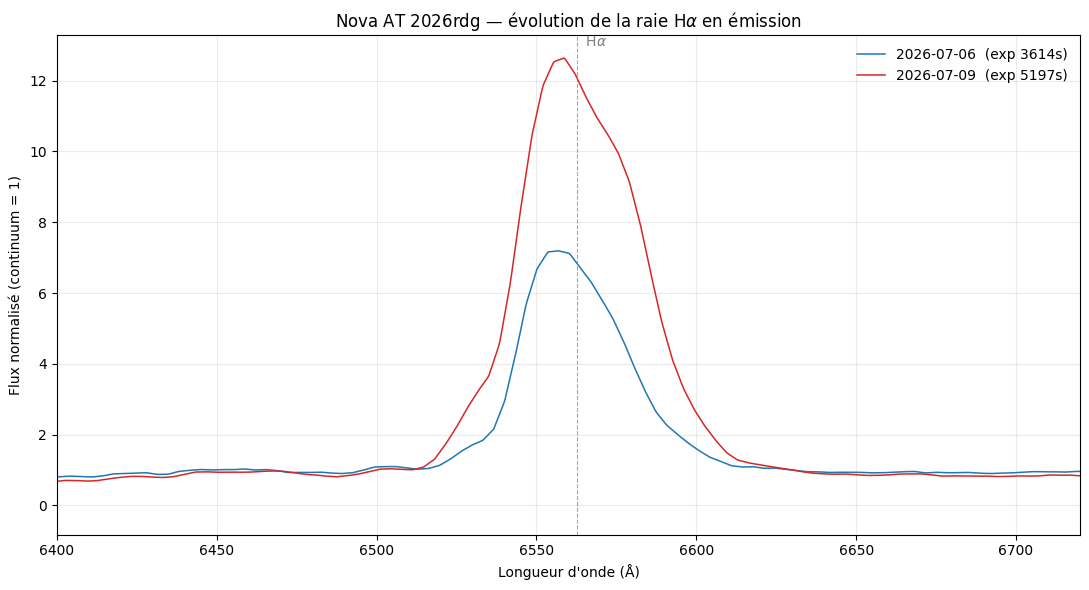

In [6]:
# --- Figure : zoom sur Hα ---
HALPHA = 6562.8
colors = {'2026-07-06': '#1f77b4', '2026-07-09': '#d62728'}

fig, ax = plt.subplots(figsize=(11, 6))
for label, (wl, flux, meta) in norm.items():
    ax.plot(wl, flux, color=colors.get(label), lw=1.1,
            label=f"{label}  (exp {int(meta['exptime'])}s)")

ax.axvline(HALPHA, color='gray', ls='--', lw=0.8, alpha=0.7)
ax.text(HALPHA, ax.get_ylim()[1], r'  H$\alpha$', color='gray',
        va='top', ha='left', fontsize=10)

ax.set_xlim(6400, 6720)
ax.set_xlabel('Longueur d\'onde (Å)')
ax.set_ylabel('Flux normalisé (continuum = 1)')
ax.set_title(r'Nova AT 2026rdg — évolution de la raie H$\alpha$ en émission')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

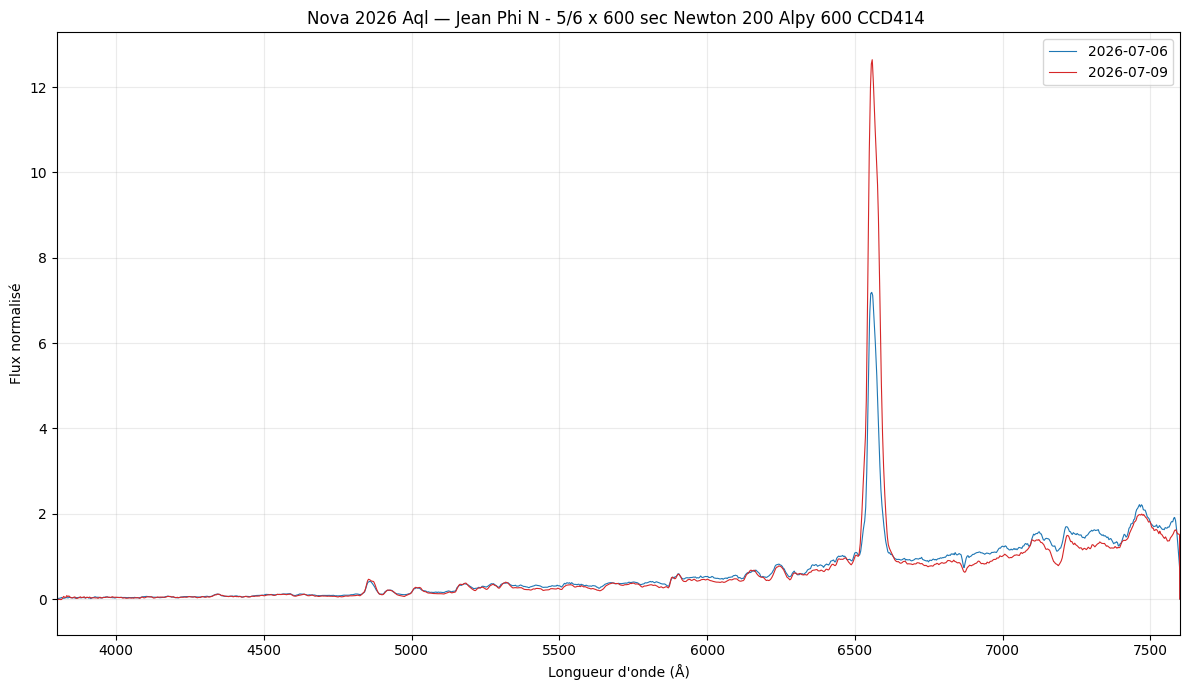

In [21]:
# --- Vue d'ensemble (spectre complet, même continuum) ---
fig, ax = plt.subplots(figsize=(12, 7))
for label, (wl, flux, meta) in norm.items():
    ax.plot(wl, flux, color=colors.get(label), lw=0.8, label=label)
ax.set_xlim(3800, 7600)
ax.set_xlabel('Longueur d\'onde (Å)')
ax.set_ylabel('Flux normalisé')
ax.set_title('Nova 2026 Aql — Jean Phi N - 5/6 x 600 sec Newton 200 Alpy 600 CCD414 ')
ax.legend(frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Colorisation physique λ→RGB + annotation des raies

Chaque spectre complet est tracé avec un **remplissage sous la courbe** coloré par la vraie couleur perçue à chaque longueur d'onde (fonction colorimétrique CIE approchée, d'après Dan Bruton). Hors du domaine visible (~3800–7000 Å) la couleur s'éteint vers le noir — c'est le comportement physique attendu : le proche-UV et le proche-IR ne sont pas perçus.

Les raies d'intérêt d'une nova classique sont annotées au-dessus du spectre.

In [8]:
# --- Fonction longueur d'onde -> RGB perceptuel (approx CIE, d'apres Dan Bruton) ---
def wavelength_to_rgb(wl_ang, gamma=0.8):
    """wl en Angstrom -> (r,g,b) dans [0,1]. Noir hors 3800-7000 A."""
    wl = wl_ang / 10.0   # Angstrom -> nm
    if wl < 380 or wl > 700:
        return (0.0, 0.0, 0.0)
    if wl < 440:
        r = -(wl - 440) / (440 - 380); g = 0.0; b = 1.0
    elif wl < 490:
        r = 0.0; g = (wl - 440) / (490 - 440); b = 1.0
    elif wl < 510:
        r = 0.0; g = 1.0; b = -(wl - 510) / (510 - 490)
    elif wl < 580:
        r = (wl - 510) / (580 - 510); g = 1.0; b = 0.0
    elif wl < 645:
        r = 1.0; g = -(wl - 645) / (645 - 580); b = 0.0
    else:
        r = 1.0; g = 0.0; b = 0.0
    # attenuation d'intensite aux bords du visible
    if wl < 420:
        f = 0.3 + 0.7 * (wl - 380) / (420 - 380)
    elif wl > 645:
        f = 0.3 + 0.7 * (700 - wl) / (700 - 645)
    else:
        f = 1.0
    return ((r * f) ** gamma, (g * f) ** gamma, (b * f) ** gamma)

# precalcul d'une table RGB sur une grille fine (accelere le remplissage)
_wl_grid = np.arange(3800, 7001, 2.0)
_rgb_grid = np.array([wavelength_to_rgb(w) for w in _wl_grid])

def rgb_at(wl_ang):
    idx = np.clip(np.searchsorted(_wl_grid, wl_ang), 0, len(_wl_grid) - 1)
    return _rgb_grid[idx]

In [17]:
# --- Raies fines (emission nova + Na I D) : label, longueur d'onde (A) ---
LINES = [
    (r"H$\delta$",      4101.7),
    (r"H$\gamma$",      4340.5),
    # (r"He I",            4471.5),
    (r"H$\beta$",       4861.3),
    # (r"[O III]",         4958.9),
    # (r"[O III]",         5006.8),
    # (r"He I",            5875.6),
    (r"Na I D",          5892.9),
    # (r"[N II]",          6548.0),
    (r"H$\alpha$",      6562.8),
    # (r"[N II]",          6583.5),
    # (r"He I",            6678.2),
    # (r"He I",            7065.2),
    # --- Fe II (multiplets dominants des novae "Fe II") ---
    (r"Fe II (42)",      4923.9),
    (r"Fe II (42)",      5018.4),
    (r"Fe II (42)",      5169.0),
    # (r"Fe II (49)",      5197.6),
    # (r"Fe II (48)",      5234.6),
    # (r"Fe II (49)",      5316.6),
    # (r"Fe II (48)",      5362.9),
    (r"Fe II (74)",      6247.6),
    (r"Fe II (74)",      6456.4),
]

# --- Bandes larges : label, (lambda_min, lambda_max) en A, categorie ---
# categorie -> couleur ('dib' interstellaire, 'tell' tellurique)
BANDS = [
    #(r"DIB 4428",   (4418.0, 4438.0), 'dib'),    # tres large, peu profonde
    #(r"DIB 6283",   (6280.0, 6288.0), 'dib'),
    (r"O$_2$ B",    (6867.0, 6884.0), 'tell'),   # bande B tellurique
    (r"H$_2$O",     (7160.0, 7340.0), 'tell'),   # vapeur d'eau
    (r"O$_2$ A",    (7594.0, 7685.0), 'tell'),   # bande A, bord rouge
]

BAND_COLORS = {'dib': 'tab:green', 'tell': 'tab:blue'}

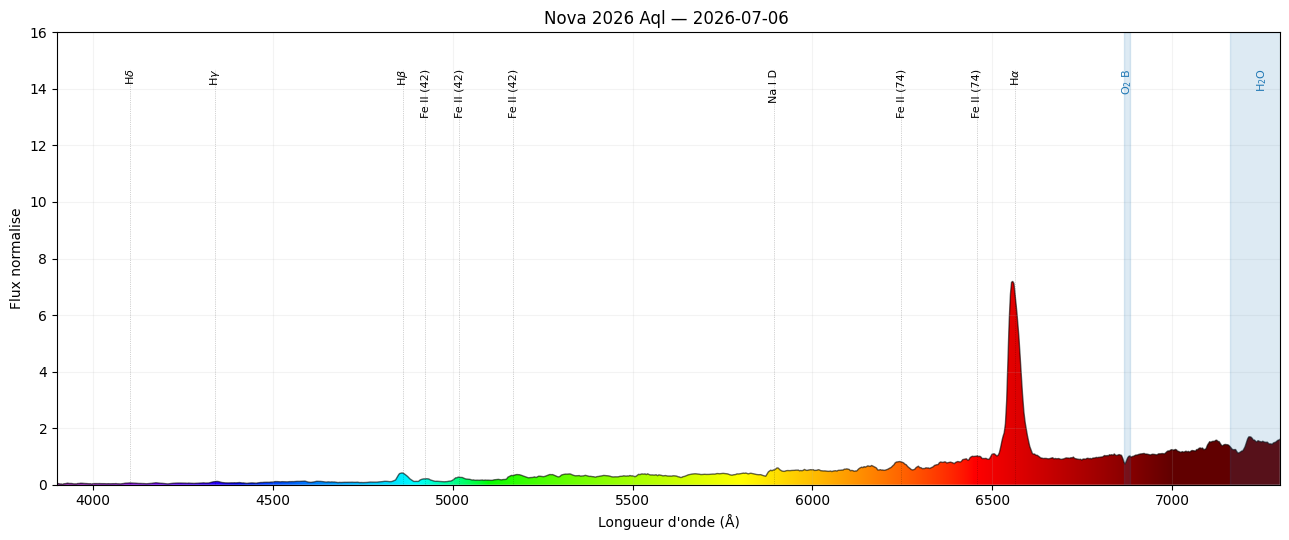

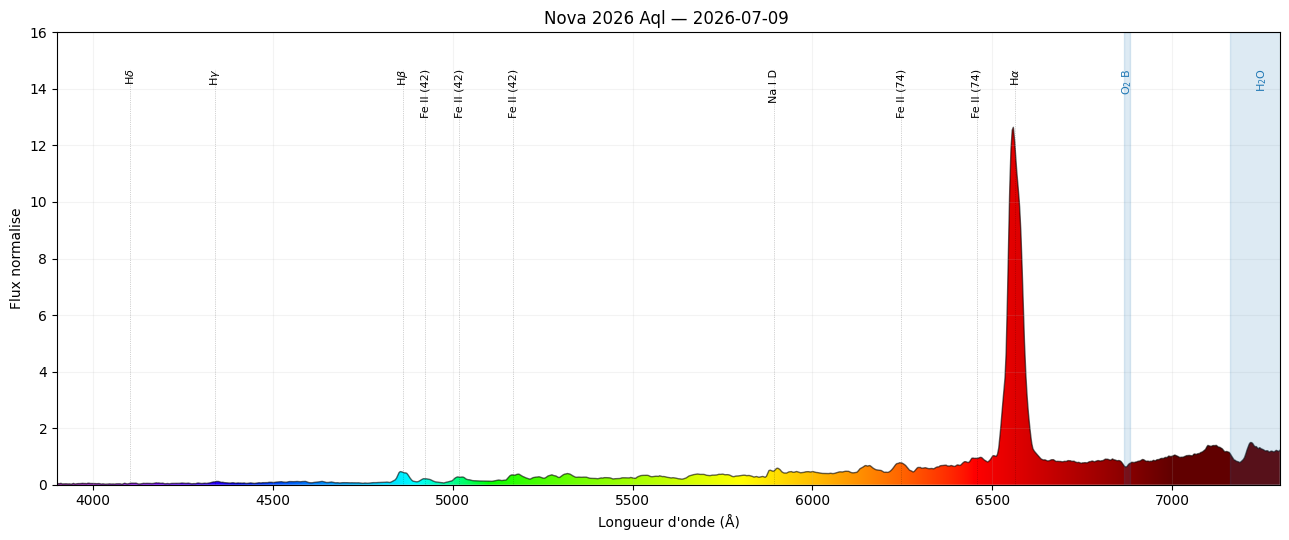

In [22]:
# --- Deux figures : spectre complet colorise + raies annotees ---
# Rendu rapide : un seul imshow du degrade, clippe sous la courbe (vs boucle fill_between).
from matplotlib.patches import Polygon

def plot_colored_spectrum(label, wl, flux, xlim=(3900, 7300)):
    m = (wl >= xlim[0]) & (wl <= xlim[1])
    w = wl[m]; y = flux[m]
    ybase = min(0.0, np.nanmin(y))
    YMAX = 16          # echelle Y commune aux deux graphes (0-16)

    fig, ax = plt.subplots(figsize=(13, 5.5))

    # bande de couleur : image 1 x N (degrade horizontal lambda->RGB), etiree en hauteur
    grad = rgb_at(w)[np.newaxis, :, :]          # shape (1, N, 3)
    im = ax.imshow(grad, extent=[w[0], w[-1], ybase, YMAX],
                   aspect='auto', origin='lower', zorder=0)

    # clip : ne garder que la zone SOUS la courbe
    verts = np.vstack([
        np.column_stack([w, y]),
        [[w[-1], ybase], [w[0], ybase]]
    ])
    clip = Polygon(verts, closed=True, transform=ax.transData)
    im.set_clip_path(clip)

    ax.plot(w, y, color='k', lw=1.0, alpha=0.6, zorder=1)

    # bandes larges (DIB, telluriques) : zone ombree + label
    for name, (lmin, lmax), cat in BANDS:
        if lmax >= xlim[0] and lmin <= xlim[1]:
            col = BAND_COLORS.get(cat, 'gray')
            ax.axvspan(lmin, lmax, color=col, alpha=0.15, zorder=2)
            ax.text((lmin + lmax) / 2, YMAX * 0.92, name, rotation=90,
                    ha='center', va='top', fontsize=8, color=col, zorder=4)

    # raies fines (emission nova, Na I D)
    for name, lam in LINES:
        if xlim[0] <= lam <= xlim[1]:
            ax.axvline(lam, color='k', ls=':', lw=0.5, alpha=0.35, ymax=0.92, zorder=3)
            ax.text(lam, YMAX * 0.92, name, rotation=90, ha='center', va='top',
                    fontsize=8, color='k', zorder=4)

    ax.set_xlim(xlim)
    ax.set_ylim(0, YMAX)
    ax.set_xlabel("Longueur d'onde (Å)")
    ax.set_ylabel('Flux normalise')
    ax.set_title(f'Nova 2026 Aql — {label} ')
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

for label, (wl, flux, meta) in norm.items():
    plot_colored_spectrum(label, wl, flux)